# Proyecto BD-141 Big Data — Fase 3: Procesamiento y Preparación de Datos

**Human Behavior AI: Detección de Manipulación Digital y Comportamiento Artificial**

| | |
|---|---|
| **Integrantes** | Mariana Méndez Pérez, Luis Diego Montero Vargas, Josué Redondo Gómez, Claret Rodríguez Jiménez, Nadin Rojas López |
| **Profesora** | Ericka Valverde Navarro |
| **Curso** | BD-141 Big Data |
| **Institución** | Colegio Universitario de Cartago |
| **Cuatrimestre** | II — 2026 |

---

## Objetivo de esta fase

Implementar los procesos de limpieza, transformación y preparación del dataset seleccionado para el proyecto, dejando los datos listos para la aplicación de modelos de Inteligencia Artificial en la Fase 4.

---
## 1. Dataset Inicial

El dataset utilizado es **Bot Detection Data**, obtenido de Kaggle. Contiene registros de actividad de usuarios en una plataforma tipo red social, con etiquetas que identifican si una cuenta es un bot (`1`) o un humano (`0`).

**Características generales:**
- 50,000 registros
- 11 columnas
- Variable objetivo: `Bot Label` (binaria: 0 = humano, 1 = bot)

In [48]:
# ============================================================
# FASE 3 — Procesamiento y Preparación de Datos
# Proyecto: Human Behavior AI
# BD-141 Big Data — CUC — Cuatrimestre II 2026
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')


### 1.1 Carga del Dataset

In [49]:
# Carga del dataset
df_raw = pd.read_csv('bot_detection_data.csv')

print("=" * 50)
print(" DATASET CARGADO EXITOSAMENTE")
print("=" * 50)
print(f"\n Filas:    {df_raw.shape[0]:,}")
print(f" Columnas: {df_raw.shape[1]}")
print(f"\n Columnas disponibles:")
for col in df_raw.columns:
    print(f"   - {col} ({df_raw[col].dtype})")

print("\n Primeras 5 filas:")
df_raw.head()

 DATASET CARGADO EXITOSAMENTE

 Filas:    50,000
 Columnas: 11

 Columnas disponibles:
   - User ID (int64)
   - Username (object)
   - Tweet (object)
   - Retweet Count (int64)
   - Mention Count (int64)
   - Follower Count (int64)
   - Verified (bool)
   - Bot Label (int64)
   - Location (object)
   - Created At (object)
   - Hashtags (object)

 Primeras 5 filas:


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


In [50]:
### 1.2 Exploración Inicial del Dataset

In [51]:
print("ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas")
print("=" * 50)
display(df_raw.describe())

print("\n Distribución de la variable objetivo (Bot Label):")
dist = df_raw['Bot Label'].value_counts()
pct  = df_raw['Bot Label'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Cantidad': dist,
    'Porcentaje (%)': pct.round(2)
})
resumen.index = ['Bot (1)', 'Humano (0)']
display(resumen)

ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas


,User ID,Retweet Count,Mention Count,Follower Count,Bot Label
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,548890.680540,50.00560,2.513760,4988.602380,0.500360
std,259756.681425,29.18116,1.708563,2878.742898,0.500005
min,100025.000000,0.00000,0.000000,0.000000,0.000000
25%,323524.250000,25.00000,1.000000,2487.750000,0.000000
50%,548147.000000,50.00000,3.000000,4991.500000,1.000000
75%,772983.000000,75.00000,4.000000,7471.000000,1.000000
max,999995.000000,100.00000,5.000000,10000.000000,1.000000



 Distribución de la variable objetivo (Bot Label):


,Cantidad,Porcentaje (%)
Bot (1),25018,50.04
Humano (0),24982,49.96


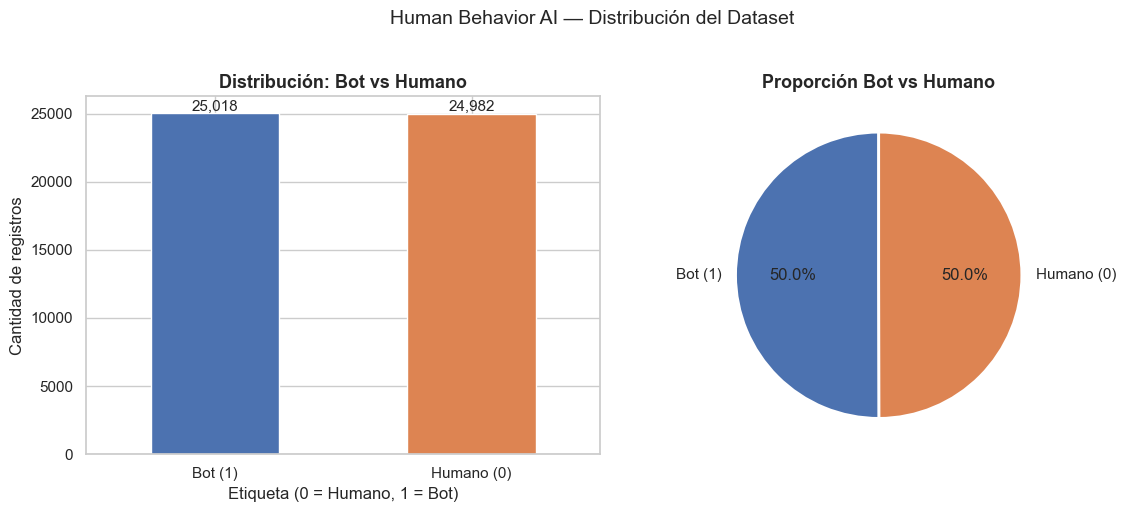

 Gráfico guardado como 'distribucion_clases.png'


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: distribución Bot vs Humano
colores = ['#4C72B0', '#DD8452']
df_raw['Bot Label'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores,
    edgecolor='white', width=0.5
)
axes[0].set_title('Distribución: Bot vs Humano', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Etiqueta (0 = Humano, 1 = Bot)')
axes[0].set_ylabel('Cantidad de registros')
axes[0].set_xticklabels(['Bot (1)', 'Humano (0)'], rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Gráfico 2: pie chart
sizes = df_raw['Bot Label'].value_counts()
axes[1].pie(sizes, labels=['Bot (1)', 'Humano (0)'],
            autopct='%1.1f%%', colors=colores,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Bot vs Humano', fontsize=13, fontweight='bold')

plt.suptitle('Human Behavior AI — Distribución del Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'distribucion_clases.png'")

---
## 2. Limpieza de Datos

En esta sección se identifican y corrigen los problemas de calidad presentes en el dataset original,
incluyendo valores nulos, duplicados, formatos incorrectos y consistencia general de los datos.

### 2.1 Detección de Valores Nulos

In [53]:
print(" ANÁLISIS DE VALORES NULOS")
print("=" * 50)

nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

reporte_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo de dato': df_raw.dtypes
})

reporte_nulos['¿Tiene nulos?'] = reporte_nulos['Valores nulos'].apply(
    lambda x: ' SÍ' if x > 0 else ' NO'
)

display(reporte_nulos)
print(f"\n Total de columnas con nulos: {(nulos > 0).sum()}")
print(f" Total de valores nulos en el dataset: {nulos.sum():,}")

 ANÁLISIS DE VALORES NULOS


,Valores nulos,Porcentaje (%),Tipo de dato,¿Tiene nulos?
User ID,0,0.00,int64,NO
Username,0,0.00,object,NO
Tweet,0,0.00,object,NO
Retweet Count,0,0.00,int64,NO
Mention Count,0,0.00,int64,NO
Follower Count,0,0.00,int64,NO
Verified,0,0.00,bool,NO
Bot Label,0,0.00,int64,NO
Location,0,0.00,object,NO
Created At,0,0.00,object,NO



 Total de columnas con nulos: 1
 Total de valores nulos en el dataset: 8,341


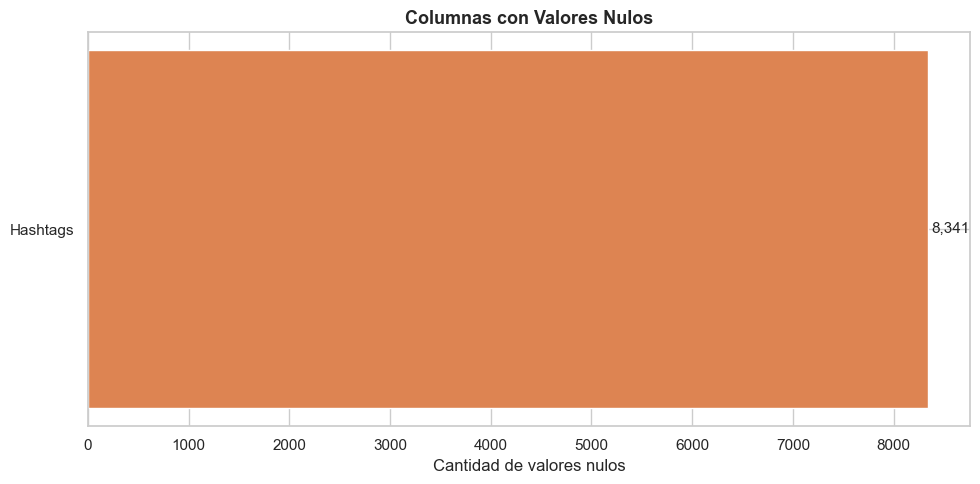

 Gráfico guardado como 'nulos_por_columna.png'


In [54]:
fig, ax = plt.subplots(figsize=(10, 5))

columnas_con_nulos = nulos[nulos > 0]

if len(columnas_con_nulos) > 0:
    bars = ax.barh(columnas_con_nulos.index, columnas_con_nulos.values,
                   color='#DD8452', edgecolor='white')
    ax.set_xlabel('Cantidad de valores nulos')
    ax.set_title('Columnas con Valores Nulos', fontsize=13, fontweight='bold')
    for bar in bars:
        ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=11)
    plt.tight_layout()
    plt.savefig('nulos_por_columna.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Gráfico guardado como 'nulos_por_columna.png'")
else:
    print(" El dataset no presenta valores nulos.")

### 2.2 Tratamiento de Valores Nulos

La columna `Hashtags` presenta **8,341 valores nulos (16.68%)**.

**Decisión tomada:** Se reemplazan por la cadena `"sin_hashtags"`.

**Justificación:** La ausencia de hashtags en un tweet es en sí misma información relevante
para la detección de bots. Eliminar esas filas implicaría perder el 16.68% del dataset,
lo cual afectaría negativamente el entrenamiento del modelo. Reemplazar con un valor
neutro identificable conserva la información de que no se usaron hashtags.

In [55]:
# Trabajamos sobre una copia para preservar el original
df = df_raw.copy()

# Tratamiento de nulos en Hashtags
df['Hashtags'] = df['Hashtags'].fillna('sin_hashtags')

# Verificación
print("TRATAMIENTO DE NULOS COMPLETADO")
print("=" * 50)
print(f"Nulos en 'Hashtags' antes: {df_raw['Hashtags'].isnull().sum():,}")
print(f"Nulos en 'Hashtags' después: {df['Hashtags'].isnull().sum()}")
print(f"\n Total de nulos restantes en el dataset: {df.isnull().sum().sum()}")

TRATAMIENTO DE NULOS COMPLETADO
Nulos en 'Hashtags' antes: 8,341
Nulos en 'Hashtags' después: 0

 Total de nulos restantes en el dataset: 0


### 2.3 Detección y Eliminación de Duplicados

In [56]:
duplicados = df.duplicated().sum()
duplicados_user = df.duplicated(subset=['User ID']).sum()

print(" ANÁLISIS DE DUPLICADOS")
print("=" * 50)
print(f"Filas completamente duplicadas:     {duplicados:,}")
print(f"User IDs duplicados:                {duplicados_user:,}")

if duplicados > 0:
    df = df.drop_duplicates()
    print(f"\n Se eliminaron {duplicados:,} filas duplicadas.")
else:
    print("\n No se encontraron filas duplicadas.")

print(f"\n Tamaño del dataset tras limpieza: {df.shape[0]:,} filas × {df.shape[1]} columnas")

 ANÁLISIS DE DUPLICADOS
Filas completamente duplicadas:     0
User IDs duplicados:                0

 No se encontraron filas duplicadas.

 Tamaño del dataset tras limpieza: 50,000 filas × 11 columnas


### 2.4 Corrección de Tipos de Datos y Formatos

In [57]:
print(" CORRECCIÓN DE TIPOS DE DATOS")
print("=" * 50)

# 1. Convertir Created At a datetime
df['Created At'] = pd.to_datetime(df['Created At'])
print(" 'Created At' convertido a datetime")

# 2. Extraer componentes de fecha útiles
df['anio_creacion']  = df['Created At'].dt.year
df['mes_creacion']   = df['Created At'].dt.month
df['hora_creacion']  = df['Created At'].dt.hour
df['dia_semana']     = df['Created At'].dt.dayofweek  # 0=Lunes, 6=Domingo
print(" Columnas de fecha extraídas: año, mes, hora, día de semana")

# 3. Estandarizar texto en columnas de cadena
df['Location'] = df['Location'].str.strip().str.title()
df['Hashtags'] = df['Hashtags'].str.strip().str.lower()
print(" Columnas de texto estandarizadas (strip + capitalización)")

# 4. Verificar tipos finales
print("\n Tipos de datos actuales:")
print(df.dtypes)

 CORRECCIÓN DE TIPOS DE DATOS
 'Created At' convertido a datetime
 Columnas de fecha extraídas: año, mes, hora, día de semana
 Columnas de texto estandarizadas (strip + capitalización)

 Tipos de datos actuales:
User ID                    int64
Username                  object
Tweet                     object
Retweet Count              int64
Mention Count              int64
Follower Count             int64
Verified                    bool
Bot Label                  int64
Location                  object
Created At        datetime64[ns]
Hashtags                  object
anio_creacion              int32
mes_creacion               int32
hora_creacion              int32
dia_semana                 int32
dtype: object


### 2.5 Resumen de la Limpieza

In [58]:
print(" RESUMEN COMPARATIVO — Antes y después de la limpieza")
print("=" * 55)

resumen_limpieza = pd.DataFrame({
    'Métrica': [
        'Total de filas',
        'Total de columnas',
        'Valores nulos',
        'Filas duplicadas',
        'Tipo de Created At',
        'Columnas derivadas de fecha'
    ],
    'Antes': [
        f"{df_raw.shape[0]:,}",
        str(df_raw.shape[1]),
        str(df_raw.isnull().sum().sum()),
        str(df_raw.duplicated().sum()),
        str(df_raw['Created At'].dtype),
        '0'
    ],
    'Después': [
        f"{df.shape[0]:,}",
        str(df.shape[1]),
        str(df.isnull().sum().sum()),
        str(df.duplicated().sum()),
        'datetime64',
        '4 (año, mes, hora, día)'
    ]
})

display(resumen_limpieza)
print("\n Limpieza completada. Dataset listo para la etapa de transformación.")

 RESUMEN COMPARATIVO — Antes y después de la limpieza


,Métrica,Antes,Después
0,Total de filas,"50,000","50,000"
1,Total de columnas,11,15
2,Valores nulos,8341,0
3,Filas duplicadas,0,0
4,Tipo de Created At,object,datetime64
5,Columnas derivadas de fecha,0,"4 (año, mes, hora, día)"



 Limpieza completada. Dataset listo para la etapa de transformación.


---
## 3. Transformaciones y Creación de Variables de Comportamiento

En esta etapa se crean nuevas variables a partir de los datos limpios. Estas variables
representan numéricamente patrones de comportamiento que los modelos de IA utilizarán
para distinguir bots de usuarios humanos.

### 3.1 Variables de Actividad y Engagement

In [59]:
print(" CREANDO VARIABLES DE ACTIVIDAD Y ENGAGEMENT")
print("=" * 55)

# 1. Ratio de engagement: interacciones totales por follower
df['engagement_ratio'] = (
    (df['Retweet Count'] + df['Mention Count']) /
    (df['Follower Count'] + 1)  # +1 para evitar división por cero
).round(4)

# 2. Actividad total: suma de retweets y menciones
df['actividad_total'] = df['Retweet Count'] + df['Mention Count']

# 3. Ratio retweet vs mención
df['ratio_retweet_mencion'] = (
    df['Retweet Count'] / (df['Mention Count'] + 1)
).round(4)

# 4. Cuenta verificada como entero (para modelos)
df['verificado_int'] = df['Verified'].astype(int)

print(" Variables creadas:")
print("   - engagement_ratio        → interacciones / seguidores")
print("   - actividad_total         → retweets + menciones")
print("   - ratio_retweet_mencion   → retweets / menciones")
print("   - verificado_int          → Verified como 0/1")

display(df[['User ID', 'engagement_ratio', 'actividad_total',
            'ratio_retweet_mencion', 'verificado_int']].head())

 CREANDO VARIABLES DE ACTIVIDAD Y ENGAGEMENT
 Variables creadas:
   - engagement_ratio        → interacciones / seguidores
   - actividad_total         → retweets + menciones
   - ratio_retweet_mencion   → retweets / menciones
   - verificado_int          → Verified como 0/1


,User ID,engagement_ratio,actividad_total,ratio_retweet_mencion,verificado_int
0,132131,0.0365,86,42.5000,0
1,289683,0.0062,60,9.1667,1
2,779715,0.0018,8,2.0000,1
3,696168,0.0263,59,9.0000,1
4,704441,0.0034,29,6.5000,0


### 3.2 Variables Temporales y de Horario

In [60]:
print(" CREANDO VARIABLES TEMPORALES")
print("=" * 55)

# 1. Franja horaria del día
def franja_horaria(hora):
    if 0 <= hora < 6:
        return 'madrugada'
    elif 6 <= hora < 12:
        return 'mañana'
    elif 12 <= hora < 18:
        return 'tarde'
    else:
        return 'noche'

df['franja_horaria'] = df['hora_creacion'].apply(franja_horaria)

# 2. Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].apply(
    lambda x: 1 if x >= 5 else 0
)

# 3. Antigüedad de la cuenta en días (respecto al registro más reciente)
fecha_referencia = df['Created At'].max()
df['antiguedad_dias'] = (fecha_referencia - df['Created At']).dt.days

print(" Variables creadas:")
print("   - franja_horaria    → madrugada / mañana / tarde / noche")
print("   - es_fin_de_semana  → 1 si sábado o domingo, 0 si no")
print("   - antiguedad_dias   → días desde creación hasta la cuenta más reciente")

display(df[['User ID', 'hora_creacion', 'franja_horaria',
            'es_fin_de_semana', 'antiguedad_dias']].head())

 CREANDO VARIABLES TEMPORALES
 Variables creadas:
   - franja_horaria    → madrugada / mañana / tarde / noche
   - es_fin_de_semana  → 1 si sábado o domingo, 0 si no
   - antiguedad_dias   → días desde creación hasta la cuenta más reciente


,User ID,hora_creacion,franja_horaria,es_fin_de_semana,antiguedad_dias
0,132131,15,tarde,0,1114
1,289683,5,madrugada,1,186
2,779715,3,madrugada,0,296
3,696168,22,noche,1,654
4,704441,21,noche,0,1142


### 3.3 Variables de Contenido (Hashtags y Tweets)

In [61]:
print("CREANDO VARIABLES DE CONTENIDO")
print("=" * 55)

# 1. Cantidad de hashtags usados
df['cantidad_hashtags'] = df['Hashtags'].apply(
    lambda x: 0 if x == 'sin_hashtags' else len(str(x).split())
)

# 2. Largo del tweet en caracteres
df['largo_tweet'] = df['Tweet'].astype(str).apply(len)

# 3. Cantidad de palabras en el tweet
df['palabras_tweet'] = df['Tweet'].astype(str).apply(
    lambda x: len(x.split())
)

# 4. Usa hashtags: flag binaria
df['usa_hashtags'] = df['cantidad_hashtags'].apply(
    lambda x: 1 if x > 0 else 0
)

print(" Variables creadas:")
print("   - cantidad_hashtags  → número de hashtags por tweet")
print("   - largo_tweet        → caracteres totales del tweet")
print("   - palabras_tweet     → palabras totales del tweet")
print("   - usa_hashtags       → 1 si usa hashtags, 0 si no")

display(df[['User ID', 'Tweet', 'cantidad_hashtags',
            'largo_tweet', 'palabras_tweet', 'usa_hashtags']].head())

CREANDO VARIABLES DE CONTENIDO
 Variables creadas:
   - cantidad_hashtags  → número de hashtags por tweet
   - largo_tweet        → caracteres totales del tweet
   - palabras_tweet     → palabras totales del tweet
   - usa_hashtags       → 1 si usa hashtags, 0 si no


,User ID,Tweet,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags
0,132131,Station activity person against natural majori...,0,83,12,0
1,289683,Authority research natural life material staff...,2,77,10,1
2,779715,Manage whose quickly especially foot none to g...,2,61,10,1
3,696168,Just cover eight opportunity strong policy which.,4,49,7,1
4,704441,Animal sign six data good or.,2,29,6,1


### 3.4 Variables de Riesgo de Bot

In [62]:
print(" CREANDO VARIABLES DE RIESGO")
print("=" * 55)

# 1. Pocos seguidores con alta actividad (patrón típico de bot)
df['alta_actividad_pocos_seguidores'] = (
    (df['Follower Count'] < df['Follower Count'].quantile(0.25)) &
    (df['actividad_total'] > df['actividad_total'].quantile(0.75))
).astype(int)

# 2. Cuenta no verificada con engagement muy alto
df['no_verif_alto_engagement'] = (
    (df['verificado_int'] == 0) &
    (df['engagement_ratio'] > df['engagement_ratio'].quantile(0.90))
).astype(int)

# 3. Actividad en madrugada (comportamiento más común en bots)
df['activo_madrugada'] = (df['franja_horaria'] == 'madrugada').astype(int)

# 4. Score de sospecha simple (suma de indicadores de riesgo)
df['score_sospecha'] = (
    df['alta_actividad_pocos_seguidores'] +
    df['no_verif_alto_engagement'] +
    df['activo_madrugada']
)

print(" Variables creadas:")
print("   - alta_actividad_pocos_seguidores  → patrón de bot clásico")
print("   - no_verif_alto_engagement         → no verificado + engagement alto")
print("   - activo_madrugada                 → actividad entre 00:00 y 06:00")
print("   - score_sospecha                   → suma de indicadores (0 a 3)")

display(df[['User ID', 'Bot Label', 'alta_actividad_pocos_seguidores',
            'no_verif_alto_engagement', 'activo_madrugada',
            'score_sospecha']].head(8))

 CREANDO VARIABLES DE RIESGO
 Variables creadas:
   - alta_actividad_pocos_seguidores  → patrón de bot clásico
   - no_verif_alto_engagement         → no verificado + engagement alto
   - activo_madrugada                 → actividad entre 00:00 y 06:00
   - score_sospecha                   → suma de indicadores (0 a 3)


,User ID,Bot Label,alta_actividad_pocos_seguidores,no_verif_alto_engagement,activo_madrugada,score_sospecha
0,132131,1,1,0,0,1
1,289683,0,0,0,1,1
2,779715,0,0,0,1,1
3,696168,1,0,0,0,0
4,704441,1,0,0,0,0
5,570928,1,0,0,0,0
6,734182,0,0,0,1,1
7,107312,1,0,0,0,0


### 3.5 Resumen de Variables del Dataset Procesado

In [63]:
columnas_originales = list(df_raw.columns)
columnas_nuevas = [c for c in df.columns if c not in columnas_originales]

print(" RESUMEN DE VARIABLES DEL DATASET PROCESADO")
print("=" * 55)
print(f"\n Columnas originales ({len(columnas_originales)}):")
for c in columnas_originales:
    print(f"   - {c}")

print(f"\n Columnas nuevas creadas ({len(columnas_nuevas)}):")
for c in columnas_nuevas:
    print(f"   + {c}")

print(f"\n Dimensiones finales: {df.shape[0]:,} filas × {df.shape[1]} columnas")

 RESUMEN DE VARIABLES DEL DATASET PROCESADO

 Columnas originales (11):
   - User ID
   - Username
   - Tweet
   - Retweet Count
   - Mention Count
   - Follower Count
   - Verified
   - Bot Label
   - Location
   - Created At
   - Hashtags

 Columnas nuevas creadas (19):
   + anio_creacion
   + mes_creacion
   + hora_creacion
   + dia_semana
   + engagement_ratio
   + actividad_total
   + ratio_retweet_mencion
   + verificado_int
   + franja_horaria
   + es_fin_de_semana
   + antiguedad_dias
   + cantidad_hashtags
   + largo_tweet
   + palabras_tweet
   + usa_hashtags
   + alta_actividad_pocos_seguidores
   + no_verif_alto_engagement
   + activo_madrugada
   + score_sospecha

 Dimensiones finales: 50,000 filas × 30 columnas


In [64]:
# Guardar el dataset procesado
df.to_csv('bot_detection_procesado.csv', index=False)

print(" Dataset procesado guardado como 'bot_detection_procesado.csv'")
print(f"   Filas:    {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"\n Listo para ser cargado en la Fase 4 — Análisis e IA")

 Dataset procesado guardado como 'bot_detection_procesado.csv'
   Filas:    50,000
   Columnas: 30

 Listo para ser cargado en la Fase 4 — Análisis e IA


---
## 4. Visualizaciones de Patrones por Categoría

En esta sección se analizan visualmente las variables más relevantes para identificar
diferencias de comportamiento entre bots y usuarios humanos.

### 4.1 Comparación de Variables Numéricas: Bot vs Humano

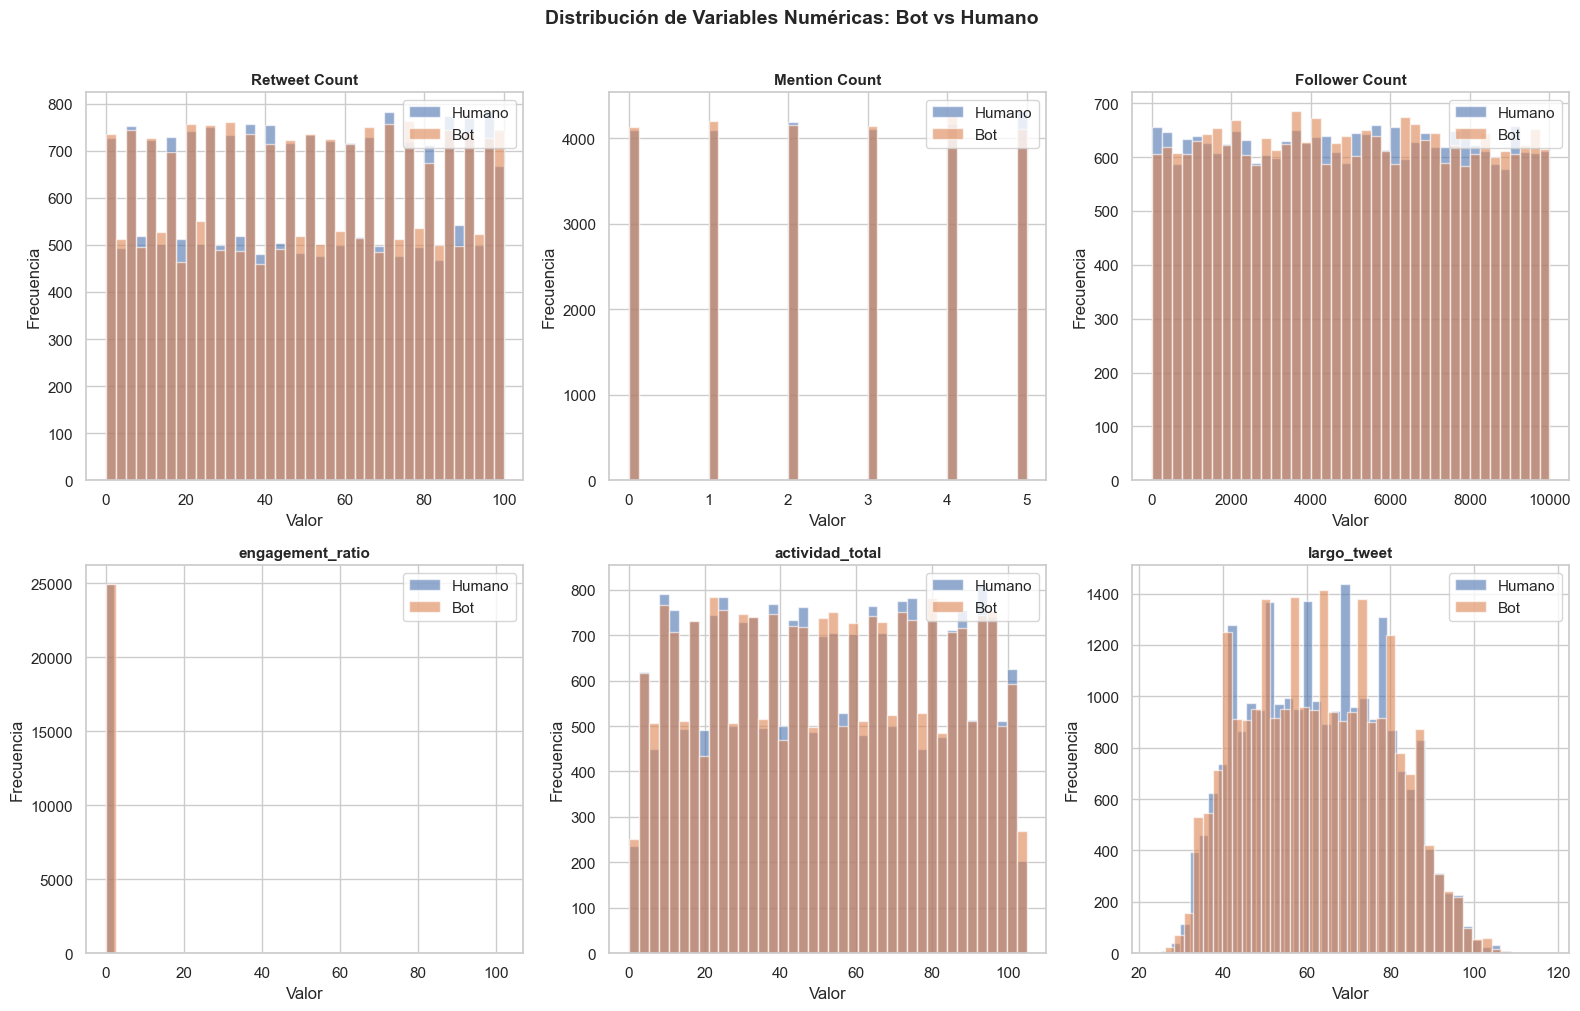

 Gráfico guardado como 'distribucion_variables_numericas.png'


In [65]:
variables_numericas = [
    'Retweet Count', 'Mention Count', 'Follower Count',
    'engagement_ratio', 'actividad_total', 'largo_tweet'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colores = {0: '#4C72B0', 1: '#DD8452'}
etiquetas = {0: 'Humano', 1: 'Bot'}

for i, var in enumerate(variables_numericas):
    for label, color in colores.items():
        subset = df[df['Bot Label'] == label][var]
        axes[i].hist(subset, bins=40, alpha=0.6,
                     color=color, label=etiquetas[label],
                     edgecolor='white')
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribución de Variables Numéricas: Bot vs Humano',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribucion_variables_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'distribucion_variables_numericas.png'")

### 4.2 Actividad por Franja Horaria

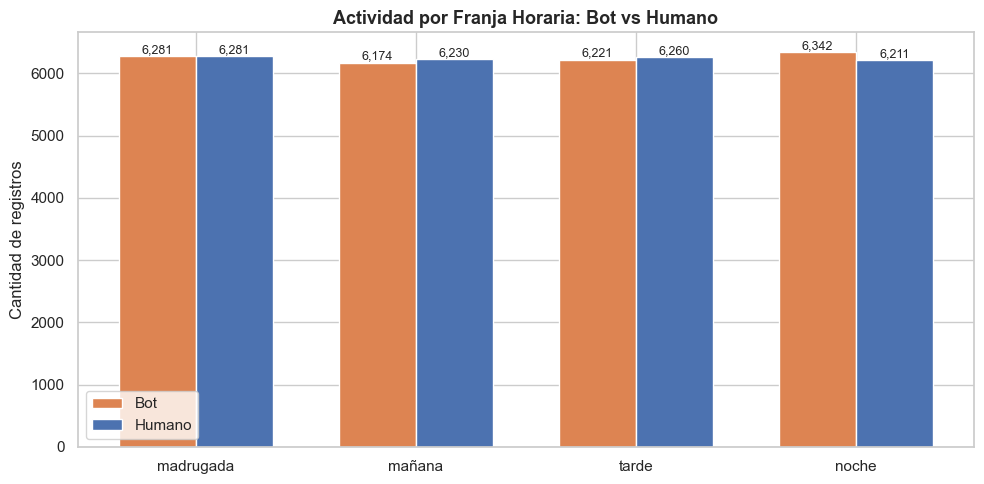

 Gráfico guardado como 'actividad_franja_horaria.png'


In [66]:
orden_franjas = ['madrugada', 'mañana', 'tarde', 'noche']

franja_bot = df[df['Bot Label'] == 1]['franja_horaria'].value_counts()
franja_hum = df[df['Bot Label'] == 0]['franja_horaria'].value_counts()

franja_df = pd.DataFrame({
    'Bot': franja_bot,
    'Humano': franja_hum
}).reindex(orden_franjas).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(orden_franjas))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], franja_df['Bot'],
               width, label='Bot', color='#DD8452', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], franja_df['Humano'],
               width, label='Humano', color='#4C72B0', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(orden_franjas, fontsize=11)
ax.set_ylabel('Cantidad de registros')
ax.set_title('Actividad por Franja Horaria: Bot vs Humano',
             fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{int(bar.get_height()):,}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('actividad_franja_horaria.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'actividad_franja_horaria.png'")

### 4.3 Score de Sospecha por Categoría

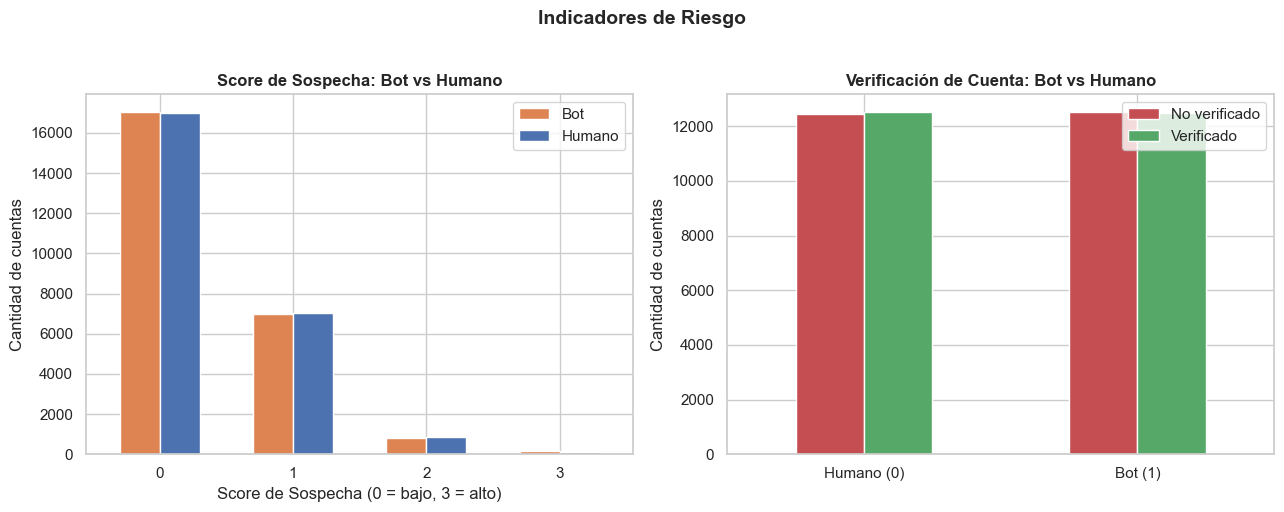

 Gráfico guardado como 'indicadores_riesgo.png'


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: distribución del score de sospecha por tipo
score_bot = df[df['Bot Label'] == 1]['score_sospecha'].value_counts().sort_index()
score_hum = df[df['Bot Label'] == 0]['score_sospecha'].value_counts().sort_index()

score_df = pd.DataFrame({'Bot': score_bot, 'Humano': score_hum}).fillna(0)

score_df.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'],
              edgecolor='white', width=0.6)
axes[0].set_title('Score de Sospecha: Bot vs Humano', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score de Sospecha (0 = bajo, 3 = alto)')
axes[0].set_ylabel('Cantidad de cuentas')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend()

# Gráfico 2: cuentas verificadas vs no verificadas por tipo
verif_df = df.groupby(['Bot Label', 'Verified']).size().unstack(fill_value=0)
verif_df.index = ['Humano (0)', 'Bot (1)']
verif_df.columns = ['No verificado', 'Verificado']
verif_df.plot(kind='bar', ax=axes[1], color=['#C44E52', '#55A868'],
              edgecolor='white', width=0.5)
axes[1].set_title('Verificación de Cuenta: Bot vs Humano', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad de cuentas')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend()

plt.suptitle('Indicadores de Riesgo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('indicadores_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'indicadores_riesgo.png'")

### 4.4 Mapa de Correlación de Variables Procesadas

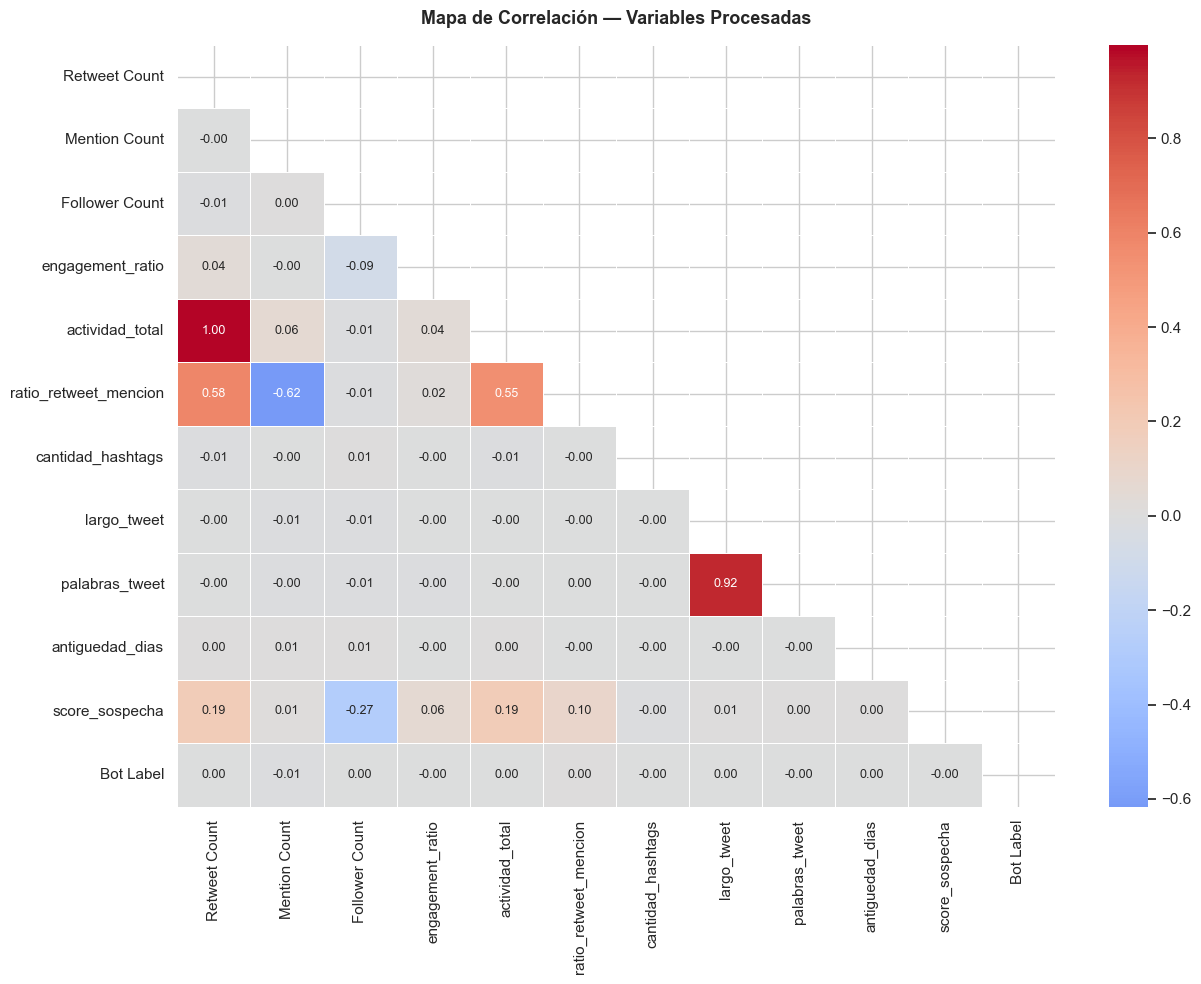

 Gráfico guardado como 'mapa_correlacion.png'


In [68]:
columnas_correlacion = [
    'Retweet Count', 'Mention Count', 'Follower Count',
    'engagement_ratio', 'actividad_total', 'ratio_retweet_mencion',
    'cantidad_hashtags', 'largo_tweet', 'palabras_tweet',
    'antiguedad_dias', 'score_sospecha', 'Bot Label'
]

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df[columnas_correlacion].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})

ax.set_title('Mapa de Correlación — Variables Procesadas',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('mapa_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado como 'mapa_correlacion.png'")

---
## 5. Problemas Encontrados y Decisiones Tomadas

Durante el procesamiento del dataset se identificaron los siguientes situaciones
y se tomaron las decisiones correspondientes para resolverlas.

In [69]:
problemas = {
    'Problema': [
        'Valores nulos en columna Hashtags',
        'Columna Created At en formato texto',
        'Columna Verified como booleano',
        'Sin variables de comportamiento directo',
        'Dataset sin columnas de sesión',
    ],
    'Descripción': [
        '8,341 registros sin hashtags (16.68% del total)',
        'No permitía operaciones de fecha ni extracción de componentes temporales',
        'Los modelos de sklearn requieren valores numéricos',
        'El dataset original solo tiene métricas brutas sin indicadores de riesgo',
        'A diferencia de lo planificado en Fase 2, el dataset no tiene session_id ni event_type',
    ],
    'Decisión tomada': [
        'Reemplazar con "sin_hashtags" para preservar registros y marcar ausencia',
        'Conversión a datetime64 con pd.to_datetime() y extracción de año, mes, hora y día',
        'Conversión a entero (0/1) con .astype(int) en columna verificado_int',
        'Creación de 12 variables derivadas: engagement, actividad, riesgo y temporales',
        'Se adaptó el diseño de variables al formato real del dataset manteniendo el enfoque analítico',
    ]
}

df_problemas = pd.DataFrame(problemas)
display(df_problemas.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#f0f0f0')]}
]))

,Problema,Descripción,Decisión tomada
0,Valores nulos en columna Hashtags,"8,341 registros sin hashtags (16.68% del total)","Reemplazar con ""sin_hashtags"" para preservar registros y marcar ausencia"
1,Columna Created At en formato texto,No permitía operaciones de fecha ni extracción de componentes temporales,"Conversión a datetime64 con pd.to_datetime() y extracción de año, mes, hora y día"
2,Columna Verified como booleano,Los modelos de sklearn requieren valores numéricos,Conversión a entero (0/1) con .astype(int) en columna verificado_int
3,Sin variables de comportamiento directo,El dataset original solo tiene métricas brutas sin indicadores de riesgo,"Creación de 12 variables derivadas: engagement, actividad, riesgo y temporales"
4,Dataset sin columnas de sesión,"A diferencia de lo planificado en Fase 2, el dataset no tiene session_id ni event_type",Se adaptó el diseño de variables al formato real del dataset manteniendo el enfoque analítico


---
## 6. Cierre de la Fase 3

### Resumen ejecutivo del procesamiento

In [70]:
print("=" * 60)
print("   FASE 3 — PROCESAMIENTO Y PREPARACIÓN DE DATOS")
print("   Human Behavior AI — BD-141 Big Data — CUC 2026")
print("=" * 60)

print(f"""
    DATASET ORIGINAL
   Filas:               {df_raw.shape[0]:,}
   Columnas:            {df_raw.shape[1]}
   Valores nulos:       {df_raw.isnull().sum().sum():,}
   Duplicados:          {df_raw.duplicated().sum()}

    LIMPIEZA REALIZADA
   Nulos tratados:      8,341 (columna Hashtags → 'sin_hashtags')
   Duplicados removidos: {df_raw.duplicated().sum()}
   Formatos corregidos: Created At → datetime64

  VARIABLES CREADAS ({len([c for c in df.columns if c not in df_raw.columns])})
   Actividad:           engagement_ratio, actividad_total, ratio_retweet_mencion
   Temporales:          franja_horaria, es_fin_de_semana, antiguedad_dias
   Contenido:           cantidad_hashtags, largo_tweet, palabras_tweet, usa_hashtags
   Riesgo:              alta_actividad_pocos_seguidores, no_verif_alto_engagement,
                        activo_madrugada, score_sospecha

 DATASET PROCESADO
   Filas:               {df.shape[0]:,}
   Columnas:            {df.shape[1]}
   Valores nulos:       {df.isnull().sum().sum()}
   Archivo guardado:    bot_detection_procesado.csv

 Dataset listo para Fase 4 — Análisis e Inteligencia Artificial
""")

   FASE 3 — PROCESAMIENTO Y PREPARACIÓN DE DATOS
   Human Behavior AI — BD-141 Big Data — CUC 2026

    DATASET ORIGINAL
   Filas:               50,000
   Columnas:            11
   Valores nulos:       8,341
   Duplicados:          0

    LIMPIEZA REALIZADA
   Nulos tratados:      8,341 (columna Hashtags → 'sin_hashtags')
   Duplicados removidos: 0
   Formatos corregidos: Created At → datetime64

  VARIABLES CREADAS (19)
   Actividad:           engagement_ratio, actividad_total, ratio_retweet_mencion
   Temporales:          franja_horaria, es_fin_de_semana, antiguedad_dias
   Contenido:           cantidad_hashtags, largo_tweet, palabras_tweet, usa_hashtags
   Riesgo:              alta_actividad_pocos_seguidores, no_verif_alto_engagement,
                        activo_madrugada, score_sospecha

 DATASET PROCESADO
   Filas:               50,000
   Columnas:            30
   Valores nulos:       0
   Archivo guardado:    bot_detection_procesado.csv

 Dataset listo para Fase 4 — Análisis

---
## 7. Carga de Datos en SQLite

En esta sección se crea la base de datos local y se cargan los datos
procesados en las tablas `raw_events` y `processed_sessions` diseñadas en la Fase 2.

In [71]:
import sqlite3
from datetime import datetime

# Crear conexión a la base de datos SQLite
conn = sqlite3.connect('humanbehaviorai.db')
cursor = conn.cursor()

# Crear tabla raw_events
cursor.execute('''
    CREATE TABLE IF NOT EXISTS raw_events (
        event_id INTEGER PRIMARY KEY AUTOINCREMENT,
        user_id TEXT,
        username TEXT,
        tweet TEXT,
        retweet_count INTEGER,
        mention_count INTEGER,
        follower_count INTEGER,
        verified INTEGER,
        bot_label INTEGER,
        location TEXT,
        created_at TEXT,
        hashtags TEXT,
        source TEXT DEFAULT 'kaggle'
    )
''')

# Crear tabla processed_sessions
cursor.execute('''
    CREATE TABLE IF NOT EXISTS processed_sessions (
        session_id INTEGER PRIMARY KEY AUTOINCREMENT,
        user_id TEXT,
        engagement_ratio REAL,
        actividad_total INTEGER,
        ratio_retweet_mencion REAL,
        franja_horaria TEXT,
        es_fin_de_semana INTEGER,
        antiguedad_dias INTEGER,
        cantidad_hashtags INTEGER,
        largo_tweet INTEGER,
        palabras_tweet INTEGER,
        usa_hashtags INTEGER,
        score_sospecha INTEGER,
        bot_label INTEGER,
        processed_at TEXT
    )
''')

conn.commit()
print("Base de datos creada exitosamente")
print("Tablas creadas: raw_events, processed_sessions")

Base de datos creada exitosamente
Tablas creadas: raw_events, processed_sessions


In [72]:
# Cargar datos en raw_events
df_raw.rename(columns={
    'User ID': 'user_id',
    'Username': 'username',
    'Tweet': 'tweet',
    'Retweet Count': 'retweet_count',
    'Mention Count': 'mention_count',
    'Follower Count': 'follower_count',
    'Verified': 'verified',
    'Bot Label': 'bot_label',
    'Location': 'location',
    'Created At': 'created_at',
    'Hashtags': 'hashtags'
}, inplace=False).to_sql('raw_events', conn, if_exists='replace', index=False)

print(f"raw_events cargada: {len(df_raw):,} registros")

# Cargar datos en processed_sessions
columnas_processed = [
    'User ID', 'engagement_ratio', 'actividad_total', 'ratio_retweet_mencion',
    'franja_horaria', 'es_fin_de_semana', 'antiguedad_dias',
    'cantidad_hashtags', 'largo_tweet', 'palabras_tweet',
    'usa_hashtags', 'score_sospecha', 'Bot Label'
]

df_processed = df[columnas_processed].copy()
df_processed.columns = [
    'user_id', 'engagement_ratio', 'actividad_total', 'ratio_retweet_mencion',
    'franja_horaria', 'es_fin_de_semana', 'antiguedad_dias',
    'cantidad_hashtags', 'largo_tweet', 'palabras_tweet',
    'usa_hashtags', 'score_sospecha', 'bot_label'
]
df_processed['processed_at'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

df_processed.to_sql('processed_sessions', conn, if_exists='replace', index=False)

print(f"processed_sessions cargada: {len(df_processed):,} registros")
print("\nCarga completada exitosamente")

raw_events cargada: 50,000 registros
processed_sessions cargada: 50,000 registros

Carga completada exitosamente


In [73]:
# Verificación de la carga
print("=== VERIFICACION DE CARGA EN BASE DE DATOS ===")
print()

# Contar registros en raw_events
cursor.execute("SELECT COUNT(*) FROM raw_events")
total_raw = cursor.fetchone()[0]
print(f"Registros en raw_events:        {total_raw:,}")

# Contar registros en processed_sessions
cursor.execute("SELECT COUNT(*) FROM processed_sessions")
total_processed = cursor.fetchone()[0]
print(f"Registros en processed_sessions: {total_processed:,}")

# Muestra de raw_events
print("\nPrimeros 3 registros de raw_events:")
df_raw_db = pd.read_sql("SELECT * FROM raw_events LIMIT 3", conn)
display(df_raw_db)

# Muestra de processed_sessions
print("\nPrimeros 3 registros de processed_sessions:")
df_proc_db = pd.read_sql("SELECT * FROM processed_sessions LIMIT 3", conn)
display(df_proc_db)

conn.close()
print("\nConexion cerrada correctamente")

=== VERIFICACION DE CARGA EN BASE DE DATOS ===

Registros en raw_events:        50,000
Registros en processed_sessions: 50,000

Primeros 3 registros de raw_events:


,user_id,username,tweet,retweet_count,mention_count,follower_count,verified,bot_label,location,created_at,hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,0,1,Adkinston,2020-05-11 15:29:50,None
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,1,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,1,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead



Primeros 3 registros de processed_sessions:


,user_id,engagement_ratio,actividad_total,ratio_retweet_mencion,franja_horaria,es_fin_de_semana,antiguedad_dias,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags,score_sospecha,bot_label,processed_at
0,132131,0.0365,86,42.5000,tarde,0,1114,0,83,12,0,1,1,2026-06-22 19:42:43
1,289683,0.0062,60,9.1667,madrugada,1,186,2,77,10,1,1,0,2026-06-22 19:42:43
2,779715,0.0018,8,2.0000,madrugada,0,296,2,61,10,1,1,0,2026-06-22 19:42:43



Conexion cerrada correctamente
